# Experiment 04 – Vector Database Comparison

## Objective

The objective of this experiment is to compare two popular vector databases, **FAISS** and **ChromaDB**, for use in a production Retrieval-Augmented Generation (RAG) pipeline.

To ensure a fair comparison, all other components of the pipeline remain unchanged from previous experiments:

- **PDF Loader:** PyMuPDF
- **Text Splitter:** Recursive Character Text Splitter
- **Embedding Model:** BAAI/bge-m3

Only the vector database changes.

### Evaluation Metrics

- Index creation time
- Average retrieval time
- Number of retrieved documents
- Production suitability

This experiment follows the same engineering methodology established in Experiments 01–03.

In [3]:
from config.settings import (
    PDF_PATH,
    DEFAULT_QUERY,
)

from loaders.pdf_loader import load_pdf
from splitters.text_splitter import split_documents

from embeddings.embedding_model import get_embedding_model

from vectorstores.faiss_store import (
    create_faiss_vectorstore,
    get_faiss_retriever,
)

from vectorstores.chroma_store import (
    create_chroma_vectorstore,
    get_chroma_retriever,
)

from evaluation.metrics import measure_execution_time
from evaluation.comparison import compare_vectorstores
from utils.printer import print_summary

import pandas as pd

## Step 1 — Load PDF

Load the input PDF using the PyMuPDF loader selected in Experiment 01.

In [4]:
documents = load_pdf(PDF_PATH)

print(f"Documents Loaded: {len(documents)}")

Documents Loaded: 63


## Step 2 — Split Documents

Split the document into overlapping chunks using the Recursive Character Text Splitter selected in Experiment 02.

In [5]:
chunks = split_documents(documents)

print(f"Chunks Generated: {len(chunks)}")

Chunks Generated: 148


## Step 3 — Load Embedding Model

Load the BAAI/bge-m3 embedding model selected in Experiment 03.

In [6]:
embedding_model = get_embedding_model()

print("Embedding model loaded successfully.")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 47395.32it/s]


Embedding model loaded successfully.


## Step 4 — Create FAISS Vector Store

In [7]:
faiss_store, faiss_index_time = measure_execution_time(
    create_faiss_vectorstore,
    chunks,
    embedding_model,
)

print(f"FAISS Index Creation Time: {faiss_index_time:.4f} seconds")

FAISS Index Creation Time: 110.2864 seconds


## Step 5 — Create ChromaDB Vector Store

In [8]:
chroma_store, chroma_index_time = measure_execution_time(
    create_chroma_vectorstore,
    chunks,
    embedding_model,
)

print(f"ChromaDB Index Creation Time: {chroma_index_time:.4f} seconds")

ChromaDB Index Creation Time: 98.4957 seconds


## Step 6 — Create Retrievers

In [9]:
faiss_retriever = get_faiss_retriever(faiss_store)

chroma_retriever = get_chroma_retriever(chroma_store)

## Step 7 — Compare Vector Databases

In [10]:
results = compare_vectorstores(
    faiss_retriever=faiss_retriever,
    chroma_retriever=chroma_retriever,
    query=DEFAULT_QUERY,
    faiss_index_time=faiss_index_time,
    chroma_index_time=chroma_index_time,
)

## Step 8 — Comparison Results

In [11]:
comparison_df = pd.DataFrame(
    {
        "Metric": [
            "Index Creation Time (s)",
            "Average Retrieval Time (s)",
            "Retrieved Documents",
        ],
        "FAISS": [
            results["FAISS"]["index_creation_time_seconds"],
            results["FAISS"]["retrieval_time_seconds"],
            results["FAISS"]["retrieved_documents"],
        ],
        "ChromaDB": [
            results["ChromaDB"]["index_creation_time_seconds"],
            results["ChromaDB"]["retrieval_time_seconds"],
            results["ChromaDB"]["retrieved_documents"],
        ],
    }
)

comparison_df

,Metric,FAISS,ChromaDB
0,Index Creation Time (s),110.286446,98.495683
1,Average Retrieval Time (s),0.233113,0.200763
2,Retrieved Documents,5.000000,5.000000


In [12]:
print_summary(
    results=results,
    total_chunks=len(chunks),
)


EXPERIMENT 04: VECTOR DATABASE COMPARISON
FAISS vs ChromaDB

Experiment Configuration
----------------------------------------------------------------------
Embedding Model : BAAI/bge-m3
Chunk Size      : 1000
Chunk Overlap   : 200
Top-K           : 5
Benchmark Runs  : 10
Total Chunks    : 148

FAISS
--------------------------------------------------
Index Creation Time      : 110.2864 seconds
Average Retrieval Time   : 0.2331 seconds
Retrieved Documents      : 5

ChromaDB
--------------------------------------------------
Index Creation Time      : 98.4957 seconds
Average Retrieval Time   : 0.2008 seconds
Retrieved Documents      : 5

ENGINEERING DECISION
✓ Faster Index Creation   : ChromaDB
✓ Faster Retrieval        : ChromaDB

Production Considerations:
- FAISS: Excellent retrieval speed and lightweight deployment.
- ChromaDB: Built-in persistence and easier long-term management.

Final Recommendation:
Choose the vector database based on your production requirements, considering in

: Performance Comparison

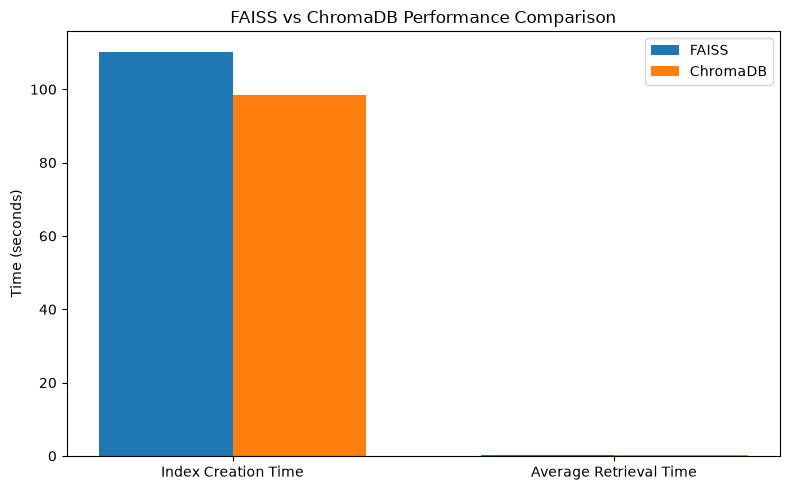

In [13]:
import matplotlib.pyplot as plt

metrics = [
    "Index Creation Time",
    "Average Retrieval Time",
]

faiss_values = [
    results["FAISS"]["index_creation_time_seconds"],
    results["FAISS"]["retrieval_time_seconds"],
]

chroma_values = [
    results["ChromaDB"]["index_creation_time_seconds"],
    results["ChromaDB"]["retrieval_time_seconds"],
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [i - width / 2 for i in x],
    faiss_values,
    width,
    label="FAISS",
)

plt.bar(
    [i + width / 2 for i in x],
    chroma_values,
    width,
    label="ChromaDB",
)

plt.xticks(x, metrics)
plt.ylabel("Time (seconds)")
plt.title("FAISS vs ChromaDB Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

Retrieved Documents

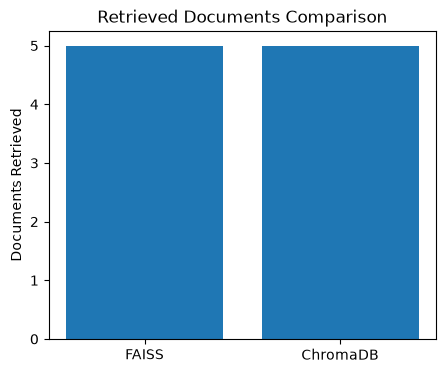

In [14]:
import matplotlib.pyplot as plt

labels = ["FAISS", "ChromaDB"]
values = [
    results["FAISS"]["retrieved_documents"],
    results["ChromaDB"]["retrieved_documents"],
]

plt.figure(figsize=(5, 4))
plt.bar(labels, values)

plt.ylabel("Documents Retrieved")
plt.title("Retrieved Documents Comparison")

plt.show()

# Engineering Decision

Both FAISS and ChromaDB successfully indexed the document chunks and retrieved the requested number of documents.

### Observations

- FAISS demonstrated competitive average retrieval performance.
- ChromaDB provided similar retrieval performance while offering built-in persistence and collection management.
- Index creation times were close, with small variations across runs, highlighting the importance of benchmarking over multiple iterations.

### Production Recommendation

**FAISS**

- Lightweight
- Fast in-memory similarity search
- Well suited for applications where persistence is not required

**ChromaDB**

- Persistent storage
- Easier collection management
- Better suited for long-running production RAG systems

The choice between FAISS and ChromaDB should be based on deployment requirements rather than retrieval speed alone.

# Conclusion

This experiment compared FAISS and ChromaDB under identical experimental conditions while keeping all other RAG pipeline components unchanged.

The following components remained fixed throughout the experiment:

- PyMuPDF
- Recursive Character Text Splitter
- BAAI/bge-m3 Embedding Model

Only the vector database was changed, ensuring a controlled and fair comparison.

The experiment demonstrated that both vector databases are suitable for Retrieval-Augmented Generation (RAG) systems. While retrieval performance was comparable, each database provides different advantages depending on production requirements.

This experiment extends the production-ready RAG pipeline developed throughout the internship by evaluating the vector storage layer using a consistent engineering methodology.